# Loan Approval Classification Dataset

Variables:
- person_age - age of a person - Float
- person_gender - gender of a person - Categorical (male, female)
- person_education	- highest education level - Categorical (Associate, Bachelor, Doctorate, High School, Master)
- person_income	- annual income	- Float
- person_emp_exp - ears of employment experience - Integer
- person_home_ownership - homeownership status - Categorical (Mortage, Other, Own, Rent)
- loan_amnt	- loan amount requested	- Float
- loan_intent - Purpose of the loan - Categorical (DebtConsolidation, Education, HomeImprovement, Medical, Personal, Venture)
- loan_int_rate	- loan interest rate - Float
- loan_percent_income - loan amount as a percentage of annual income - Float
- cb_person_cred_hist_length - length of credit history in years - Float
- credit_score - credit score of the person	- Integer (in points)
- previous_loan_defaults_on_file - indicator of previous loan defaults	- Categorical (Yes, No)
- loan_status - loan approval status - Integer(1 = approved; 0 = rejected)

In [387]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTENC
from collections import Counter

dataset = pd.read_csv('loan_data.csv')
print(dataset.shape)
dataset.head()

(45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [388]:
dataset.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

## 1. Data Exploration & Preprocessing

In [389]:
print('Missing values:')
missing_values = dataset.isnull().sum()
if any(missing_values.values > 0):
    for column, count in missing_values.items():
        if count > 0:
            print(f"- {column}: {count}")
else:
    print('No missing values')

Missing values:
No missing values


In [390]:
numeric_cols = dataset.select_dtypes(include=['number']).columns.difference(['loan_status'])
categorical_cols = dataset.select_dtypes(include=['object']).columns

print("Numeric columns summary")
display(dataset[numeric_cols].describe().T.round(2))

print("\nCategorical columns summary")
display(dataset[categorical_cols].describe(include='object').T)

Numeric columns summary


,count,mean,std,min,25%,50%,75%,max
cb_person_cred_hist_length,45000.0,5.87,3.88,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.61,50.44,390.00,601.00,640.00,670.00,850.00
loan_amnt,45000.0,9583.16,6314.89,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.01,2.98,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.14,0.09,0.00,0.07,0.12,0.19,0.66
person_age,45000.0,27.76,6.05,20.00,24.00,26.00,30.00,144.00
person_emp_exp,45000.0,5.41,6.06,0.00,1.00,4.00,8.00,125.00
person_income,45000.0,80319.05,80422.50,8000.00,47204.00,67048.00,95789.25,7200766.00



Categorical columns summary


,count,unique,top,freq
person_gender,45000,2,male,24841
person_education,45000,5,Bachelor,13399
person_home_ownership,45000,4,RENT,23443
loan_intent,45000,6,EDUCATION,9153
previous_loan_defaults_on_file,45000,2,Yes,22858


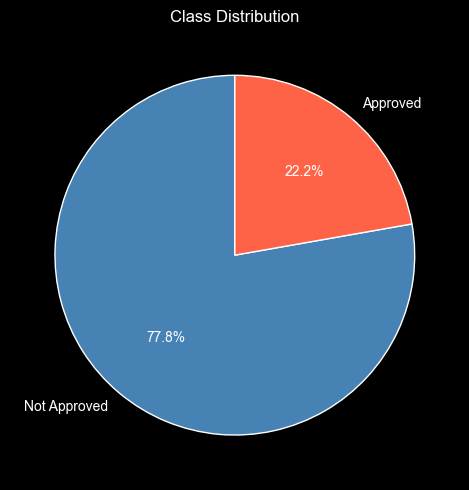

In [391]:
counts = dataset['loan_status'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts, labels=['Not Approved', 'Approved'], autopct='%1.1f%%',
       colors=['steelblue', 'tomato'], startangle=90)
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

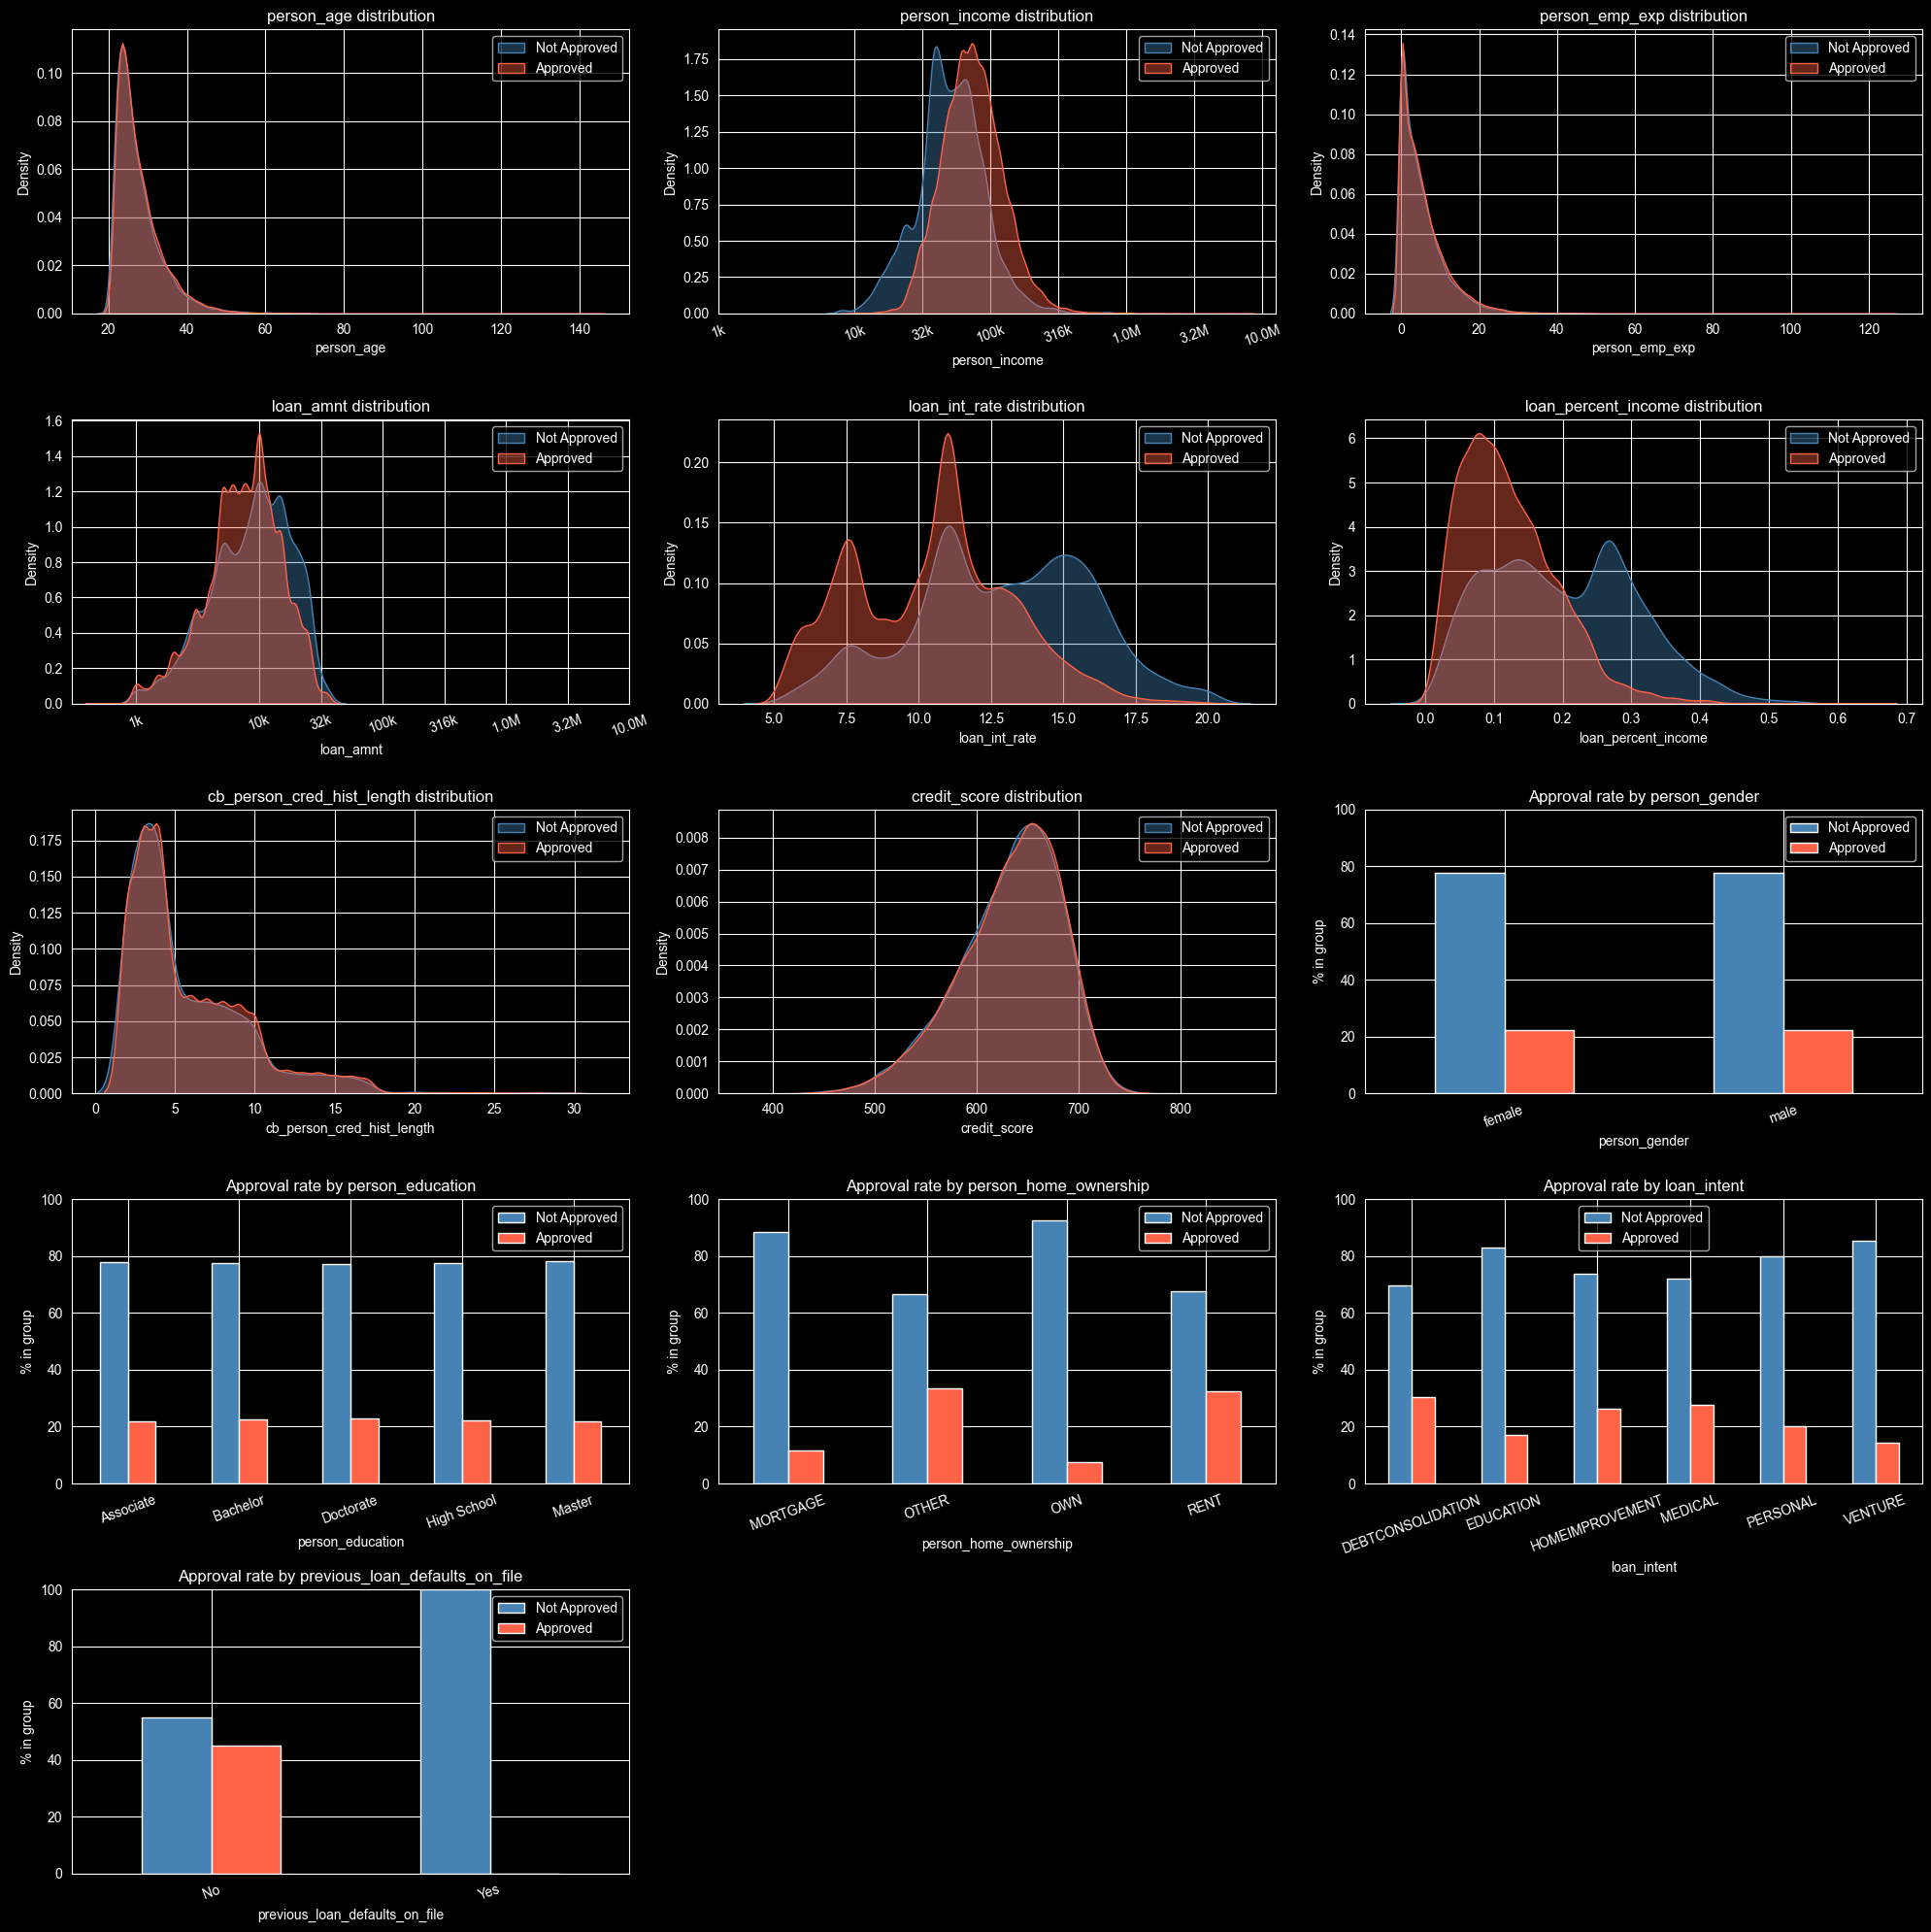

In [392]:
num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'previous_loan_defaults_on_file']

all_cols = num_cols + cat_cols
n = len(all_cols)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()


skewed_cols = ['person_income', 'loan_amnt']
log_y_cols = ['person_emp_exp', 'cb_person_cred_hist_length']

def human_format(x, pos):
    if x >= 1_000_000: return f'{x/1_000_000:.1f}M'
    if x >= 1_000: return f'{x/1_000:.0f}k'
    return str(int(x))

skewed_cols = ['person_income', 'loan_amnt']

for ax, col in zip(axes, all_cols):
    if col in num_cols:
        data0 = dataset[dataset['loan_status']==1][col]
        data1 = dataset[dataset['loan_status']==0][col]

        if col in skewed_cols:
            sns.kdeplot(np.log10(data0), ax=ax, label='Not Approved', color='steelblue', fill=True, alpha=0.4)
            sns.kdeplot(np.log10(data1), ax=ax, label='Approved', color='tomato', fill=True, alpha=0.4)
            ticks = [3, 4, 4.5, 5, 5.5, 6, 6.5, 7]
            ax.set_xticks(ticks)
            ax.set_xticklabels([human_format(10**t, None) for t in ticks], rotation=20)
            ax.set_xlabel(col)
        else:
            sns.kdeplot(data0, ax=ax, label='Not Approved', color='steelblue', fill=True, alpha=0.4)
            sns.kdeplot(data1, ax=ax, label='Approved', color='tomato', fill=True, alpha=0.4)
            ax.set_xlabel(col)

        ax.set_title(f'{col} distribution')
        ax.set_ylabel('Density')
        ax.legend()

    else:
        ct = pd.crosstab(dataset[col], dataset['loan_status'], normalize='index') * 100
        ct.columns = ['Not Approved', 'Approved']
        ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], rot=20)
        ax.set_title(f'Approval rate by {col}')
        ax.set_ylabel('% in group')
        ax.set_ylim(0, 100)
        ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

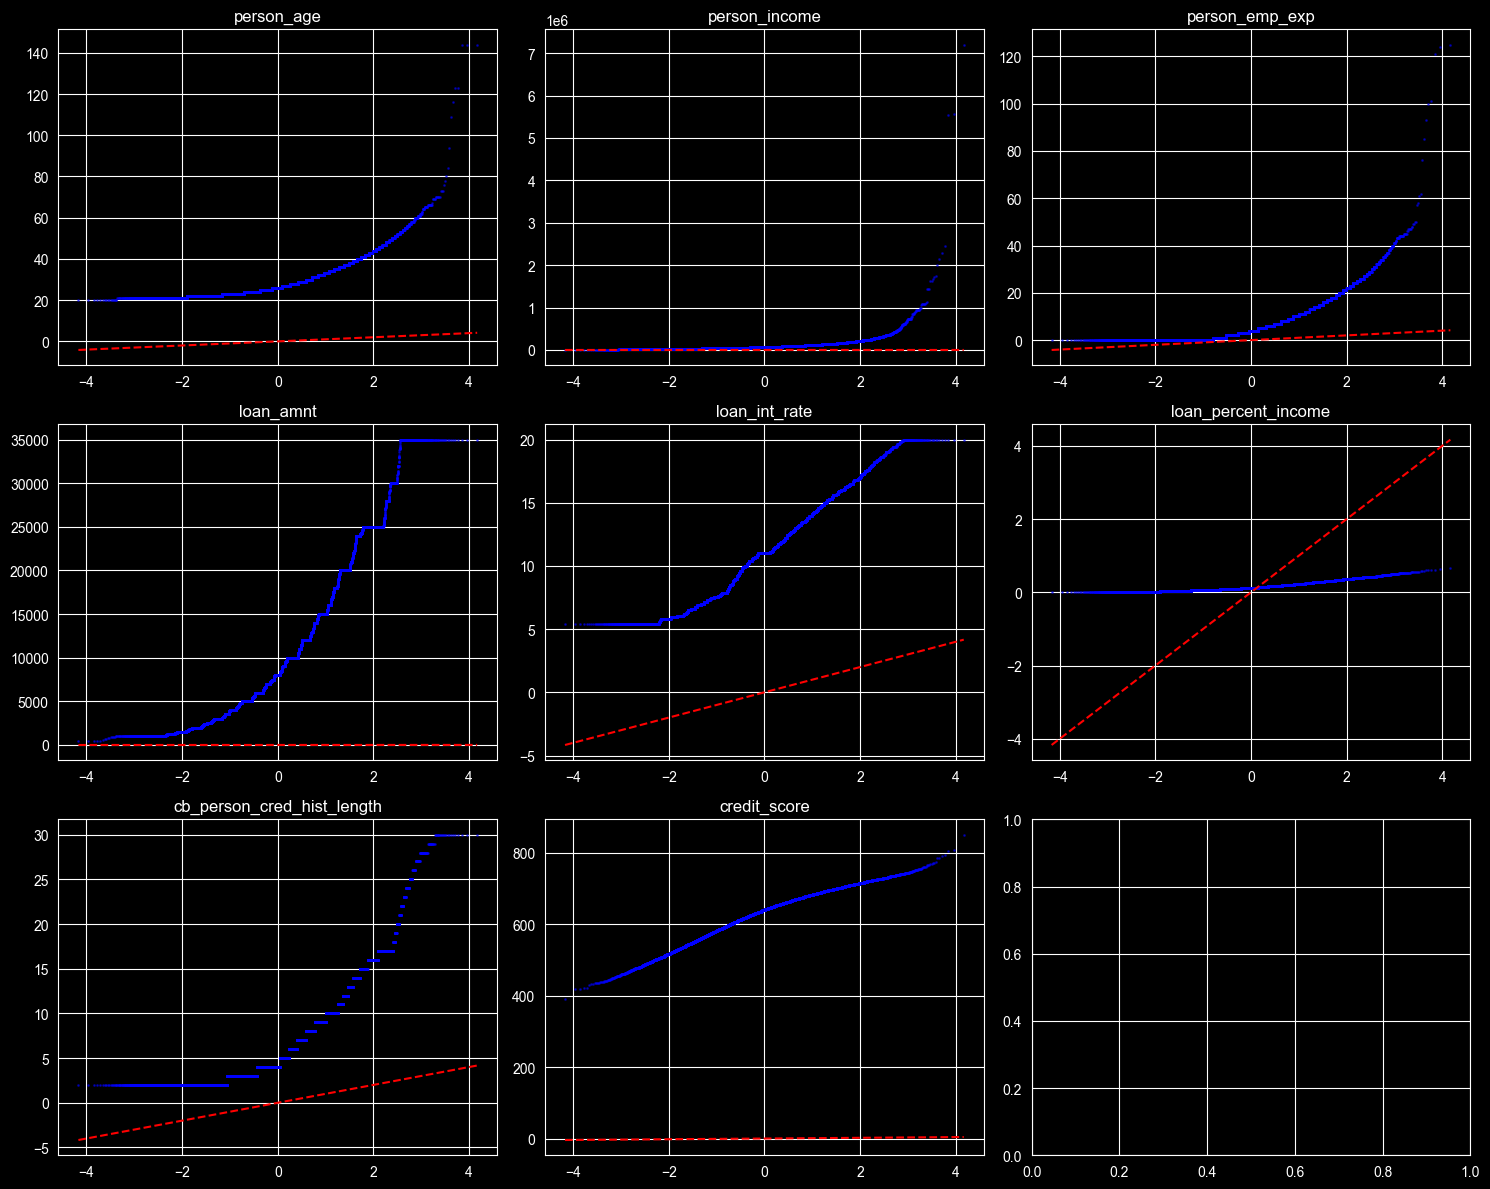

In [393]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    (osm, osr), (slope, intercept, r) = stats.probplot(dataset[col], dist="norm")

    axes[i].scatter(osm, osr, alpha=0.5, s=1, color='blue')

    min_val = min(osm)
    max_val = max(osm)
    axes[i].plot([min_val, max_val], [min_val, max_val],
                 'r--', linewidth=1.5)

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [394]:
df = dataset.copy()

le = LabelEncoder()
cat_encode_cols = ['person_gender', 'person_education', 'person_home_ownership',
                   'loan_intent', 'previous_loan_defaults_on_file']

encodings = {}
for col in cat_encode_cols:
    df[col] = le.fit_transform(df[col])

    unique_classes = le.classes_
    encoding_mapping = {i: class_name for i, class_name in enumerate(unique_classes)}
    encodings[col] = encoding_mapping
    print(encoding_mapping.items())

dict_items([(0, 'female'), (1, 'male')])
dict_items([(0, 'Associate'), (1, 'Bachelor'), (2, 'Doctorate'), (3, 'High School'), (4, 'Master')])
dict_items([(0, 'MORTGAGE'), (1, 'OTHER'), (2, 'OWN'), (3, 'RENT')])
dict_items([(0, 'DEBTCONSOLIDATION'), (1, 'EDUCATION'), (2, 'HOMEIMPROVEMENT'), (3, 'MEDICAL'), (4, 'PERSONAL'), (5, 'VENTURE')])
dict_items([(0, 'No'), (1, 'Yes')])


In [395]:
df.describe()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000.000000,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,0.552022,1.743933,8.031905e+04,5.410333,1.696622,9583.157556,2.525911,11.006606,0.139725,5.867489,632.608756,0.507956,0.222222
std,6.045108,0.497292,1.479148,8.042250e+04,6.063532,1.440497,6314.886691,1.728305,2.978808,0.087212,3.879702,50.435865,0.499942,0.415744
min,20.000000,0.000000,0.000000,8.000000e+03,0.000000,0.000000,500.000000,0.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,4.720400e+04,1.000000,0.000000,5000.000000,1.000000,8.590000,0.070000,3.000000,601.000000,0.000000,0.000000
50%,26.000000,1.000000,1.000000,6.704800e+04,4.000000,3.000000,8000.000000,3.000000,11.010000,0.120000,4.000000,640.000000,1.000000,0.000000
75%,30.000000,1.000000,3.000000,9.578925e+04,8.000000,3.000000,12237.250000,4.000000,12.990000,0.190000,8.000000,670.000000,1.000000,0.000000
max,144.000000,1.000000,4.000000,7.200766e+06,125.000000,3.000000,35000.000000,5.000000,20.000000,0.660000,30.000000,850.000000,1.000000,1.000000


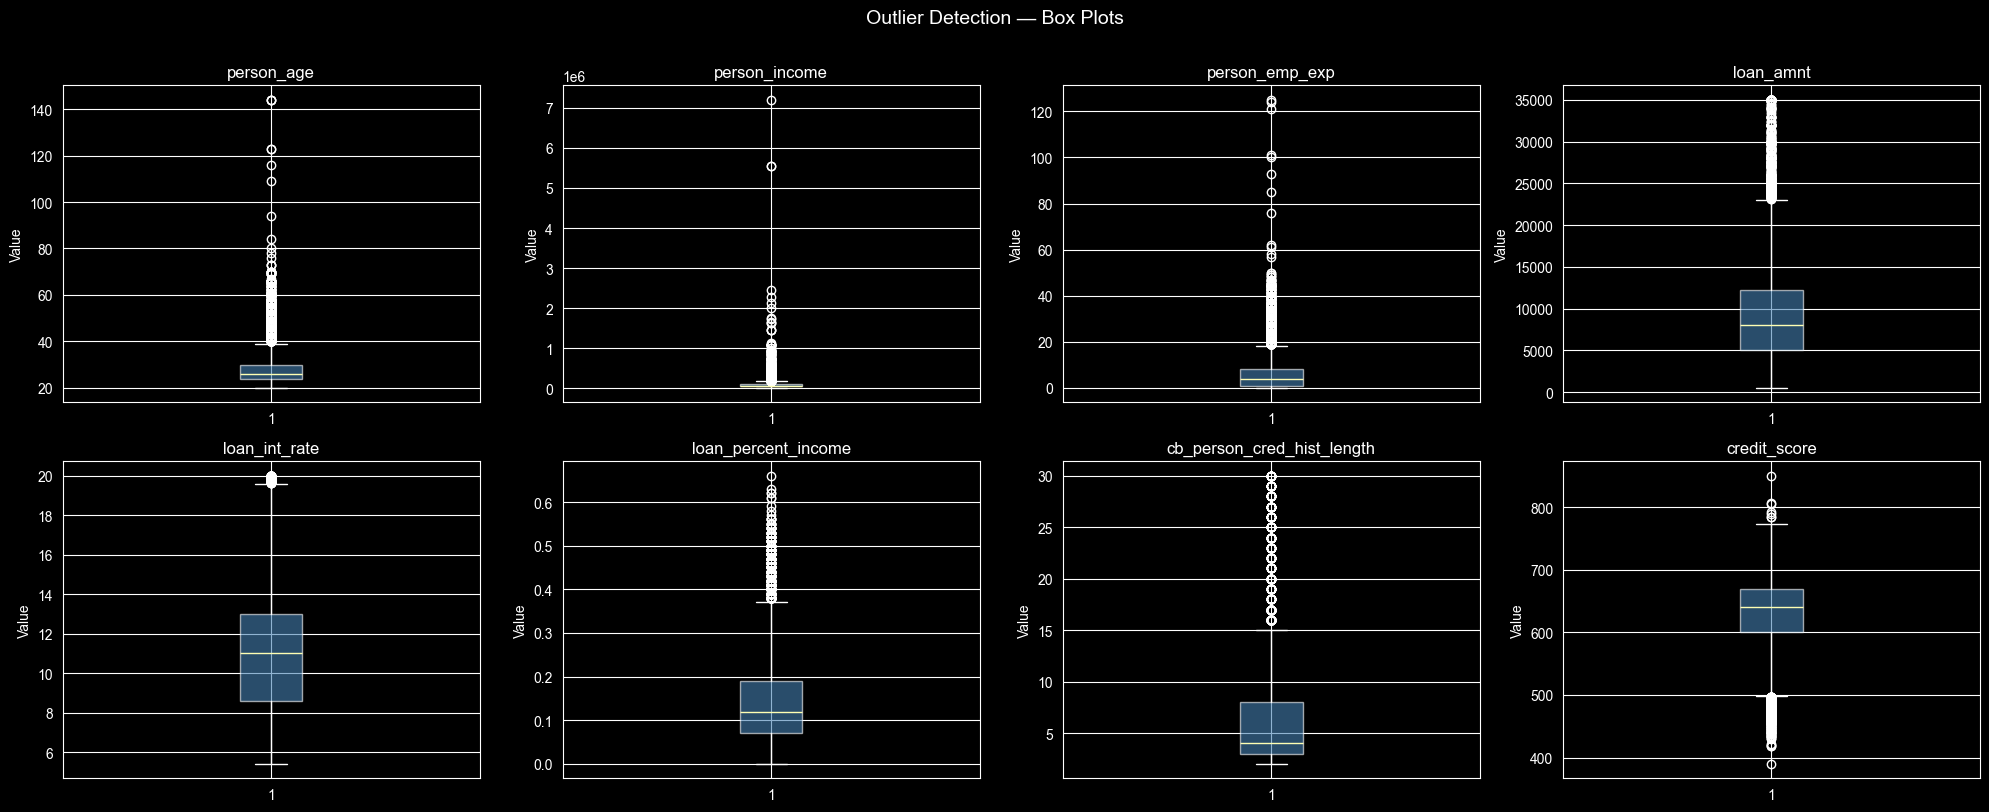

Feature                               Outliers       %           Min          Max
person_age                                2188    4.9%         20.00       144.00
person_income                             2218    4.9%       8000.00   7200766.00
person_emp_exp                            1724    3.8%          0.00       125.00
loan_amnt                                 2348    5.2%        500.00     35000.00
loan_int_rate                              124    0.3%          5.42        20.00
loan_percent_income                        744    1.7%          0.00         0.66
cb_person_cred_hist_length                1366    3.0%          2.00        30.00
credit_score                               467    1.0%        390.00       850.00

After capping:
  person_age max:    100.0
  person_emp_exp max: 60
  person_income max:  271,450


In [396]:
outlier_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel('Value')
plt.suptitle('Outlier Detection — Box Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"{'Feature':<35} {'Outliers':>10} {'%':>7}  {'Min':>12} {'Max':>12}")
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    n = mask.sum()
    print(f"{col:<35} {n:>10} {n/len(df)*100:>6.1f}%  {df[col].min():>12.2f} {df[col].max():>12.2f}")

df['person_age'] = df['person_age'].clip(upper=100)
df['person_emp_exp'] = df['person_emp_exp'].clip(upper=60)

income_cap = df['person_income'].quantile(0.99)
df['person_income'] = df['person_income'].clip(upper=income_cap)

print(f"\nAfter capping:")
print(f"  person_age max:    {df['person_age'].max()}")
print(f"  person_emp_exp max: {df['person_emp_exp'].max()}")
print(f"  person_income max:  {df['person_income'].max():,.0f}")

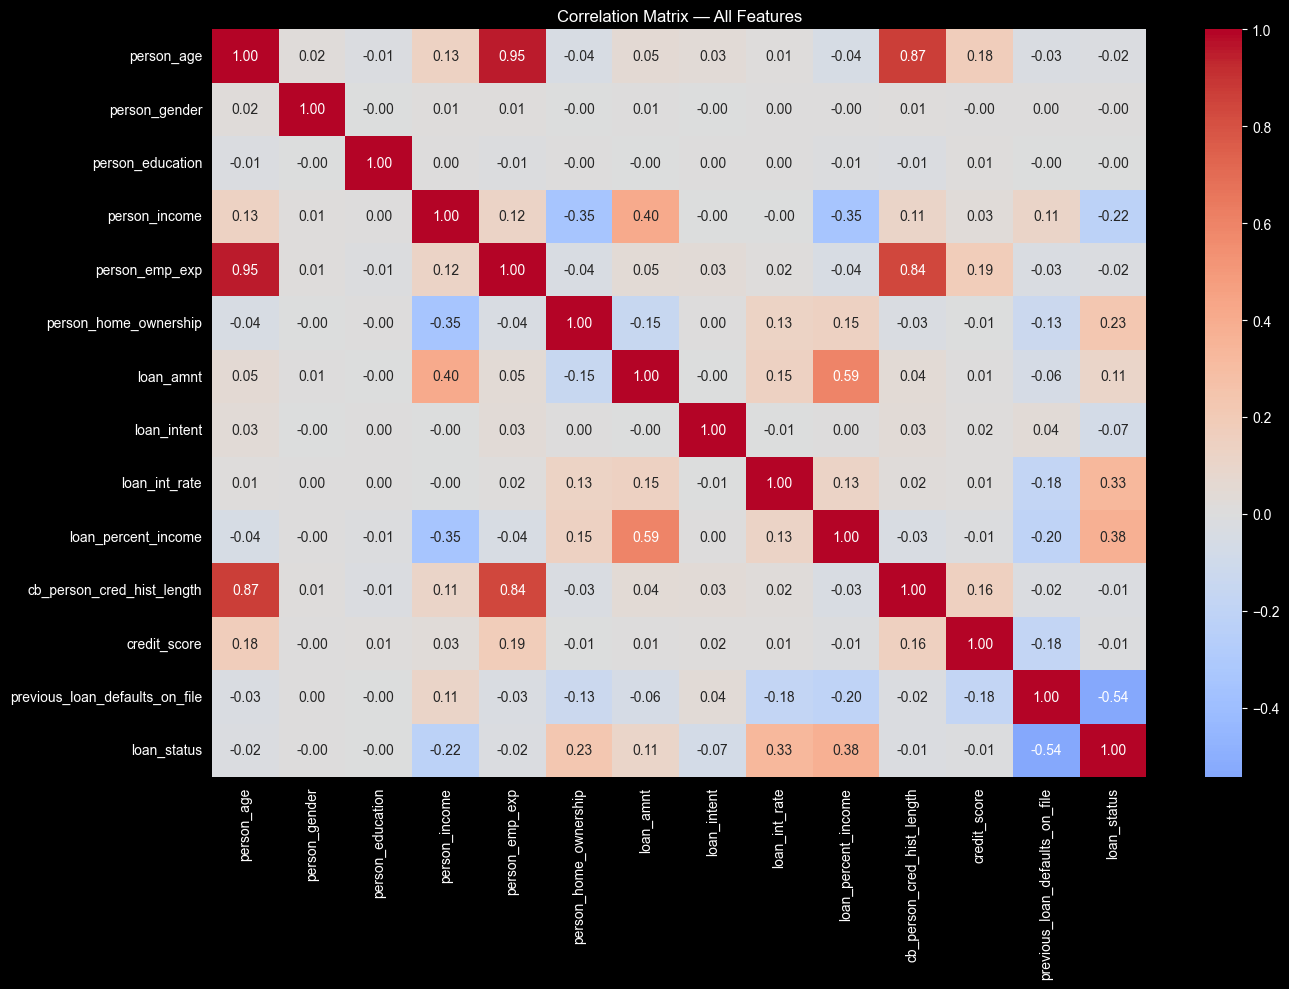

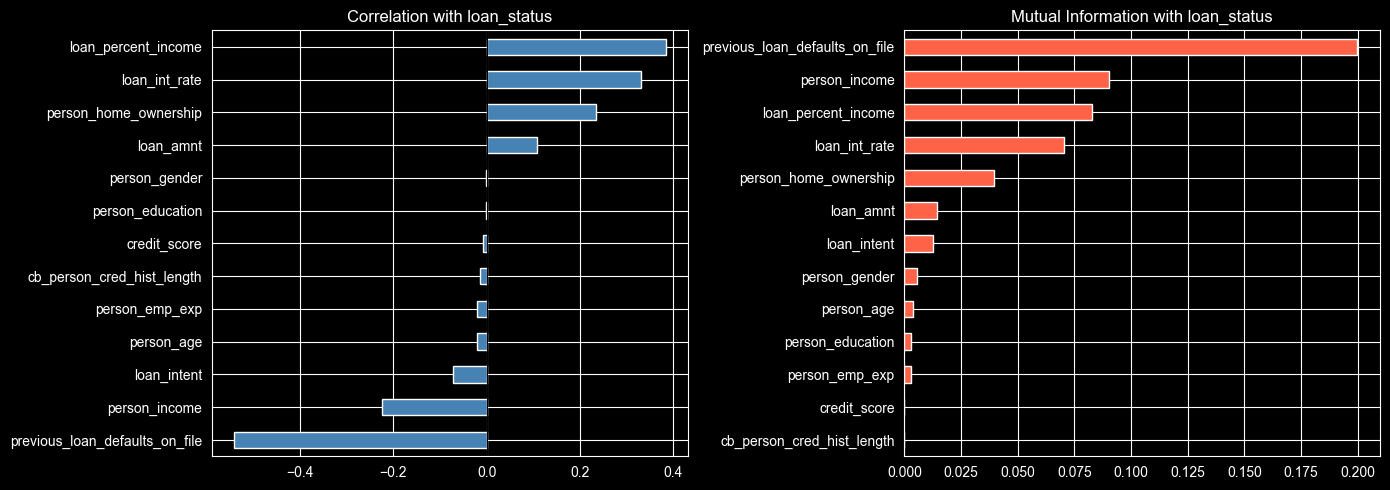

In [397]:
from sklearn.feature_selection import mutual_info_classif

corr_all = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — All Features')
plt.tight_layout()
plt.show()

mi = mutual_info_classif(df.drop(columns=['loan_status']), df['loan_status'], random_state=42)
mi_series = pd.Series(mi, index=df.drop(columns=['loan_status']).columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
corr_all['loan_status'].drop('loan_status').sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Correlation with loan_status')
axes[0].axvline(0, color='black', linewidth=0.8)

mi_series.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Mutual Information with loan_status')

plt.tight_layout()
plt.show()

Dropped: ['person_age', 'person_gender', 'person_education', 'person_emp_exp', 'loan_amnt', 'loan_intent', 'cb_person_cred_hist_length', 'credit_score']


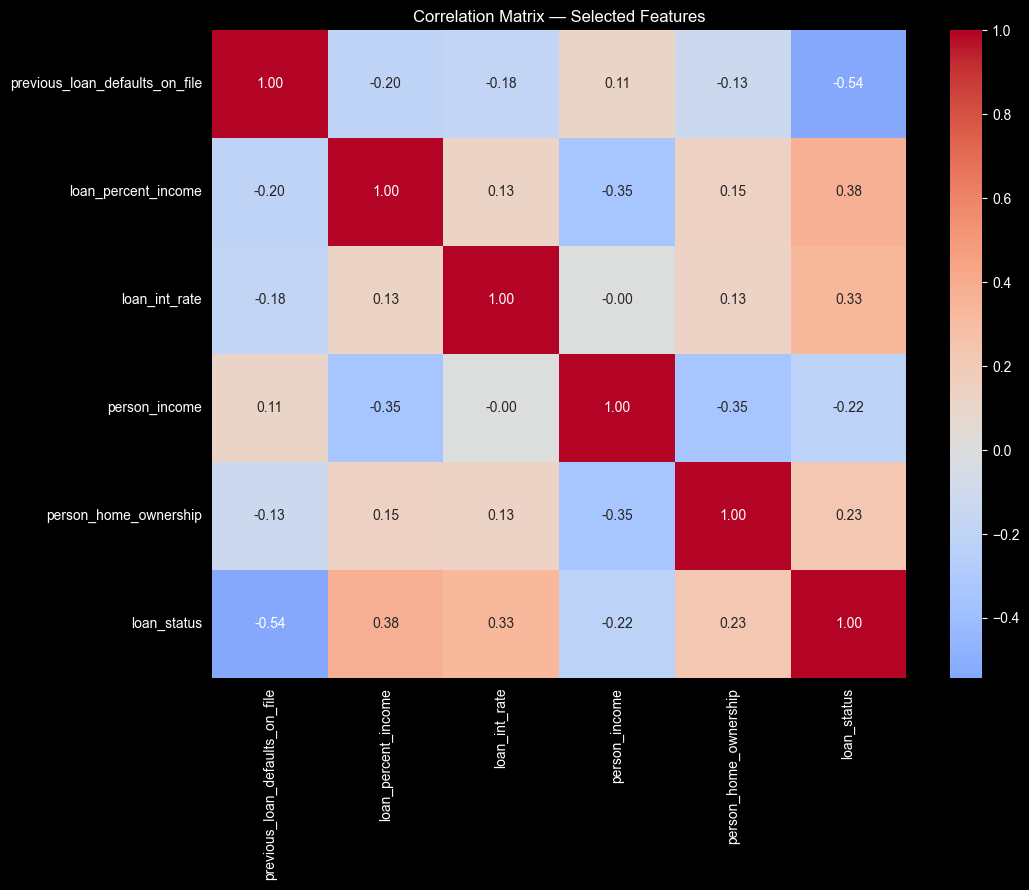

In [398]:
selected_features = ['previous_loan_defaults_on_file', 'loan_percent_income',
                     'loan_int_rate', 'person_income', 'person_home_ownership']
dropped_features = [c for c in df.columns if c not in selected_features + ['loan_status']]
print(f"Dropped: {dropped_features}")

corr_sel = df[selected_features + ['loan_status']].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_sel, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Selected Features')
plt.tight_layout()
plt.show()

In [399]:
X = df[selected_features]
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

categorical_idx = [X_train.columns.get_loc(col) for col in  ['previous_loan_defaults_on_file', 'person_home_ownership']]
smote = SMOTENC(categorical_features=categorical_idx, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Training set size:", X_train_sc.shape)
print("Test set size:", X_test_sc.shape)
print("Class distribution in train:", Counter(y_train))
print("Class distribution in test:", Counter(y_test))

/Users/vika/PycharmProjects/DataMining/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vika/PycharmProjects/DataMining/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Training set size: (56000, 5)
Test set size: (9000, 5)
Class distribution in train: Counter({0: 28000, 1: 28000})
Class distribution in test: Counter({0: 7000, 1: 2000})


## 2. 1-Rule (OneR) Classifier



In [400]:
oner = DecisionTreeClassifier(max_depth=1, random_state=42)
oner.fit(X_train_sc, y_train)
y_pred_oner = oner.predict(X_test_sc)

best_feat = selected_features[oner.tree_.feature[0]]
threshold = oner.tree_.threshold[0]
print(f"1R best feature: '{best_feat}' (threshold={threshold:.2f})")
print(f"Accuracy: {accuracy_score(y_test, y_pred_oner):.4f}")
print(classification_report(y_test, y_pred_oner, target_names=['Not Approved', 'Approved']))

1R best feature: 'previous_loan_defaults_on_file' (threshold=0.37)
Accuracy: 0.7328
              precision    recall  f1-score   support

Not Approved       1.00      0.66      0.79      7000
    Approved       0.45      1.00      0.62      2000

    accuracy                           0.73      9000
   macro avg       0.73      0.83      0.71      9000
weighted avg       0.88      0.73      0.76      9000



## 3. Naive Bayes

In [401]:
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)

print("Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb, target_names=['Not Approved', 'Approved']))

Naive Bayes
Accuracy: 0.7336
              precision    recall  f1-score   support

Not Approved       1.00      0.66      0.79      7000
    Approved       0.45      1.00      0.63      2000

    accuracy                           0.73      9000
   macro avg       0.73      0.83      0.71      9000
weighted avg       0.88      0.73      0.76      9000



## 4. Decision Tree

Decision Tree
Accuracy: 0.8754
              precision    recall  f1-score   support

Not Approved       0.96      0.88      0.92      7000
    Approved       0.67      0.86      0.75      2000

    accuracy                           0.88      9000
   macro avg       0.81      0.87      0.84      9000
weighted avg       0.89      0.88      0.88      9000



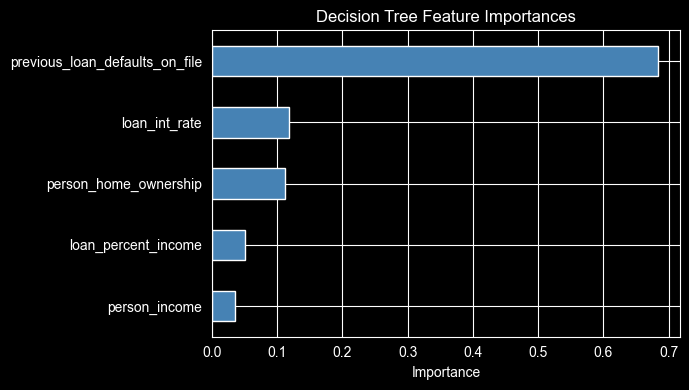

In [402]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

print("Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Not Approved', 'Approved']))

fi = pd.Series(dt.feature_importances_, index=selected_features).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(7, 4), color='steelblue')
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [403]:
from sklearn.tree import export_text

tree_text = export_text(dt, feature_names=selected_features)
print(tree_text)

|--- previous_loan_defaults_on_file <= 0.37
|   |--- person_home_ownership <= 0.35
|   |   |--- loan_int_rate <= 0.10
|   |   |   |--- person_income <= -1.06
|   |   |   |   |--- loan_percent_income <= -0.41
|   |   |   |   |   |--- loan_int_rate <= -0.22
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- loan_int_rate >  -0.22
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- loan_percent_income >  -0.41
|   |   |   |   |   |--- class: 1
|   |   |   |--- person_income >  -1.06
|   |   |   |   |--- loan_int_rate <= -1.02
|   |   |   |   |   |--- person_income <= 0.03
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- person_income >  0.03
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- loan_int_rate >  -1.02
|   |   |   |   |   |--- person_home_ownership <= -0.38
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- person_home_ownership >  -0.38
|   |   |   |   |   |   |--- class: 0
|   |   |--- loan_int_rate >  0.10
|   |   |   |--

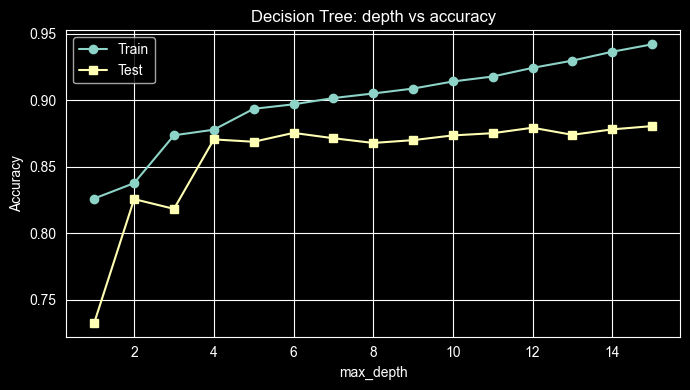

In [404]:
depths = range(1, 16)
dt_train_scores, dt_test_scores = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_sc, y_train)
    dt_train_scores.append(accuracy_score(y_train, clf.predict(X_train_sc)))
    dt_test_scores.append(accuracy_score(y_test, clf.predict(X_test_sc)))

plt.figure(figsize=(7, 4))
plt.plot(depths, dt_train_scores, label='Train', marker='o')
plt.plot(depths, dt_test_scores, label='Test', marker='s')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: depth vs accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. k-Nearest Neighbors

kNN
Accuracy: 0.8707
              precision    recall  f1-score   support

Not Approved       0.96      0.87      0.91      7000
    Approved       0.66      0.87      0.75      2000

    accuracy                           0.87      9000
   macro avg       0.81      0.87      0.83      9000
weighted avg       0.89      0.87      0.88      9000



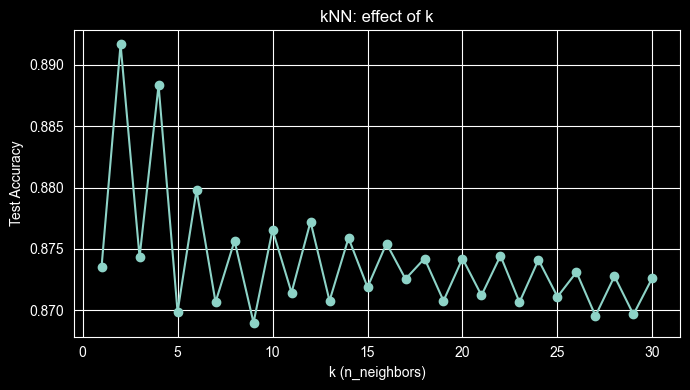

Best k = 2, accuracy = 0.8917


In [405]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

print("kNN")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn, target_names=['Not Approved', 'Approved']))

k_vals = range(1, 31)
knn_scores = []
for k in k_vals:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    knn_scores.append(accuracy_score(y_test, clf.predict(X_test_sc)))

plt.figure(figsize=(7, 4))
plt.plot(k_vals, knn_scores, marker='o')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Test Accuracy')
plt.title('kNN: effect of k')
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = list(k_vals)[np.argmax(knn_scores)]
print(f"Best k = {best_k}, accuracy = {max(knn_scores):.4f}")

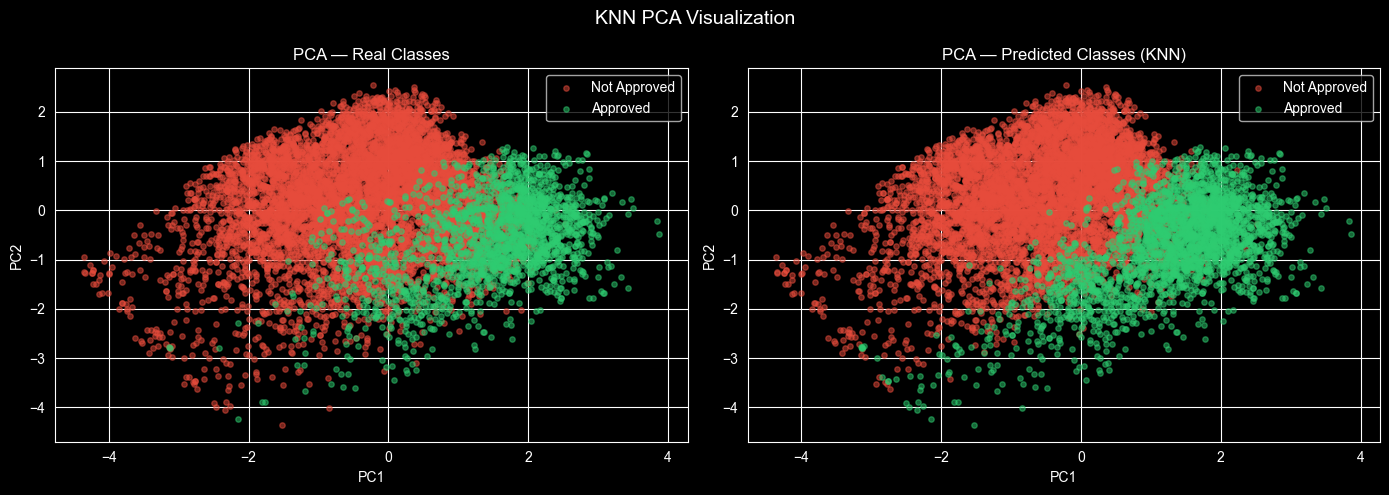

In [406]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#2ecc71']
labels = ['Not Approved', 'Approved']

for cls, color, label in zip([0, 1], colors, labels):
    mask = y_test == cls
    axes[0].scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                    c=color, label=label, alpha=0.5, s=15)
axes[0].set_title('PCA — Real Classes')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

for cls, color, label in zip([0, 1], colors, labels):
    mask = y_pred_knn == cls
    axes[1].scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                    c=color, label=label, alpha=0.5, s=15)
axes[1].set_title('PCA — Predicted Classes (KNN)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'KNN PCA Visualization', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Comparative Analysis

               Accuracy  F1 (approved)  F1 (macro)
Classifier                                        
1-Rule         0.732778       0.624512    0.708548
Naive Bayes    0.733556       0.625195    0.709253
Decision Tree  0.875444       0.754758    0.835641
kNN            0.870667       0.749893    0.831338


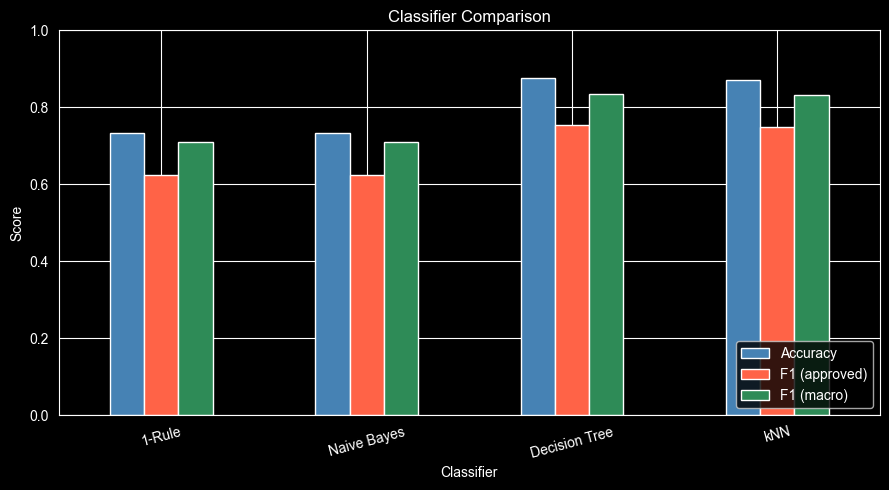

In [407]:
results = {
    '1-Rule': y_pred_oner,
    'Naive Bayes':    y_pred_nb,
    'Decision Tree':  y_pred_dt,
    'kNN':      y_pred_knn,
}

summary = []
for name, y_pred in results.items():
    summary.append({
        'Classifier': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (approved)': f1_score(y_test, y_pred),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
    })

summary_df = pd.DataFrame(summary).set_index('Classifier')
print(summary_df.to_string())

summary_df.plot(kind='bar', figsize=(9, 5), rot=15, ylim=(0, 1),
                color=['steelblue', 'tomato', 'seagreen'])
plt.title('Classifier Comparison')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

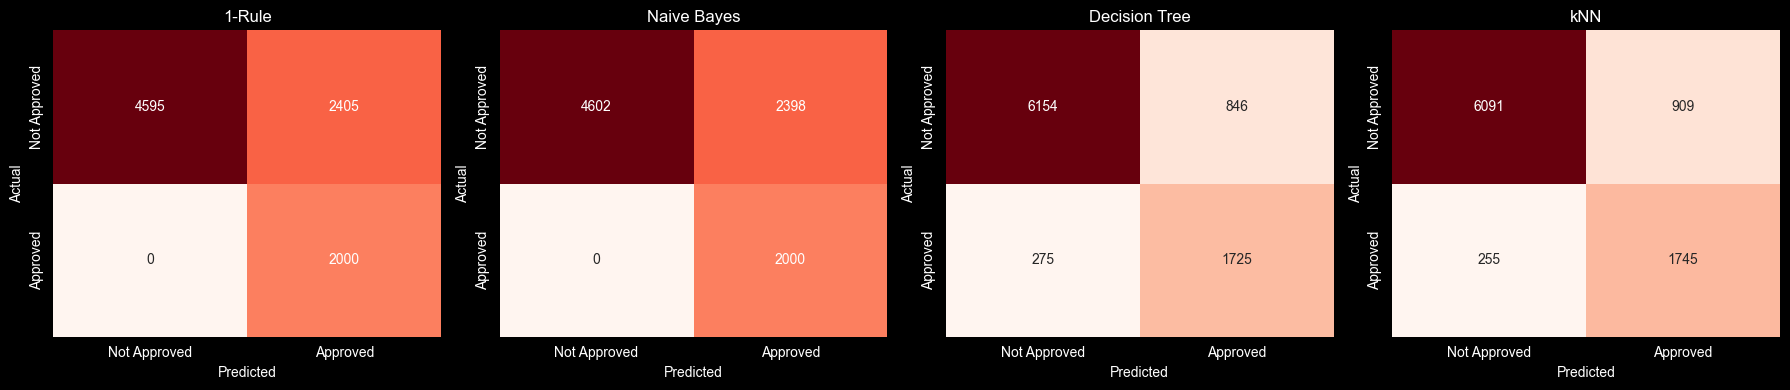

In [408]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
labels = ['Not Approved', 'Approved']
for ax, (name, y_pred) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()